# Project 1 — Predicting m-Height from Random Polytope Data

**Goal:**  
Use machine learning to approximate the *m-height* (output of a linear-program computation) as a function of the input matrix P and parameters (n, k, m).  
We will build a robust, high-accuracy regression model using modern ensemble methods.

**Core challenge:**  
The true m-height values come from solving linear programs, which can be noisy and heavy-tailed.  
This project requires careful feature design, outlier control, and model blending to achieve stable generalization.

**Pipeline overview**
1. Feature engineering from P (flattened and statistical descriptors)  
2. Adaptive outlier trimming per (k,m) bucket  
3. Stage A – Robust Gradient Boosting Regressor  
4. Stage B – KNN residual correction  
5. Evaluation → MAE, RMSE, R², log₂ MSE
6. Save trained models for reproducible grading
7. Final cell for grading


In [2]:
import os, pickle, math, numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


## Step 1 — Load and Inspect Data

We begin by loading the merged dataset (`MERGED_all_inputs.pkl`, `MERGED_all_outputs.pkl`) which together contain approximately 60 K samples.  
Each record has:
- `(n, k, m)` – problem size parameters  
- `P` – a k × (n–k) matrix of coefficients  
- `y` – computed m-height (target)

We verify counts and check for finite positive targets before preprocessing.


In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
# core
import os, math, pickle, numpy as np
from collections import defaultdict

# ml
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# reproducibility
SEED = 636
np.random.seed(SEED)
tf.random.set_seed(SEED)

# === edit BASE_DIR if your files are elsewhere ===
BASE_DIR = r"/content/drive/MyDrive"

# merged ~60k dataset
PATH_X = os.path.join(BASE_DIR, "MERGED_all_inputs.pkl")   # list of [n,k,m,P]
PATH_Y = os.path.join(BASE_DIR, "MERGED_all_outputs.pkl")  # list/array of floats


print("TensorFlow:", tf.__version__)



TensorFlow: 2.19.0


In [3]:
with open(PATH_X, "rb") as f: X_list = pickle.load(f)
with open(PATH_Y, "rb") as f: y_list = pickle.load(f)

print("Samples:", len(X_list))
print("Example [n,k,m]:", X_list[0][:3], "P shape:", X_list[0][3].shape, "y:", y_list[0])



Samples: 60000
Example [n,k,m]: [9, 4, 2] P shape: (4, 5) y: 11.472222222222221


In [4]:
import numpy as np
from collections import defaultdict

# Assumes X_list, y_list already loaded (merged). If you still have the original 32k indices, prefer those here.
y_all = np.maximum(1.0, np.array(y_list, dtype=np.float64))
y_log_all = np.log2(y_all)

km_to_idx = defaultdict(list)
for i,(n,k,m,P) in enumerate(X_list):
    km_to_idx[(k,m)].append(i)

clean_mask = np.zeros(len(X_list), dtype=bool)
for km, idxs in km_to_idx.items():
    vals = y_log_all[idxs]
    lo, hi = np.percentile(vals, [5, 95])   # gentle trim
    # mark indices to keep
    keep = (vals >= lo) & (vals <= hi)
    # prefer the first 32k if you know which they are; otherwise just keep by range
    for j, ok in zip(idxs, keep):
        if ok:
            clean_mask[j] = True

# Apply mask
X_clean = [x for x, keep in zip(X_list, clean_mask) if keep]
y_clean = [y for y, keep in zip(y_list, clean_mask) if keep]
print(f"Kept {len(X_clean)} / {len(X_list)} samples after per-bucket 5–95% filter.")


Kept 53996 / 60000 samples after per-bucket 5–95% filter.


## 🧭 Step 2 — Exploratory Data Analysis (EDA)

Before diving into preprocessing or model training, we perform an **Exploratory Data Analysis (EDA)** to understand the structure, scale, and distribution of the dataset.  
This step reveals potential transformations, normalization strategies, and modeling choices that improve learning stability.

### 🎯 EDA Objectives
- Inspect dataset composition across `(k, m)` buckets and verify shape consistency of matrices `P`.
- Examine the **target variable (`m-height`)** distribution to assess skewness and justify the **log₂ transformation**.
- Explore **input matrix P** distributions, magnitudes, and variability to determine an appropriate scaling factor.
- Visualize **sample P heatmaps** and **SVD spectra** to identify structural or rank-related patterns.
- Study per-bucket spread of `log₂(m-height)` to motivate **per-bucket modeling**.

### 🧩 Structure of this section
Each of the following EDA cells focuses on a distinct aspect:
- **C1 — Target Distribution:** Analyze raw and log₂-transformed m-height values.  
- **C2 — P Distribution:** Study the range and scaling of input matrix P.  
- **C3 — Random P Heatmaps:** Visualize representative matrices to detect structural differences.  
- **C4 — SVD Spectrum:** Evaluate singular-value trends and complexity across samples.  
- **C5 — Per-(k,m) Target Spread:** Compare log₂(m-height) variability between buckets.

### 🧠 Key Takeaway
By understanding how targets and features behave *before* preprocessing, we can:
- Choose meaningful scaling constants (e.g., `P_SCALE = 100`),
- Train in **log₂-space** to stabilize variance,
- And design specialized **per-(k,m)** models that align with bucket-specific distributions.

> The insights from this section directly influence our preprocessing pipeline and model architecture defined in **Step 3**.


### C1 — Distribution of Target (m-height)

Before any preprocessing or modeling, it’s crucial to understand how the target variable `m-height` behaves.  
This cell visualizes both **raw** and **log₂-transformed** distributions of `m-height` to check for skewness or heavy tails.

- The **raw distribution** reveals whether certain m-heights dominate.
- The **log₂ transform** compresses long tails, stabilizing variance and helping gradient-based models.
- Summary statistics (min, mean, median, max) quantify spread.

**Insight:**  
If the raw `m-height` is heavily right-skewed, it justifies training the model in log₂-space, since that reduces the impact of large outliers and produces more stable gradients.


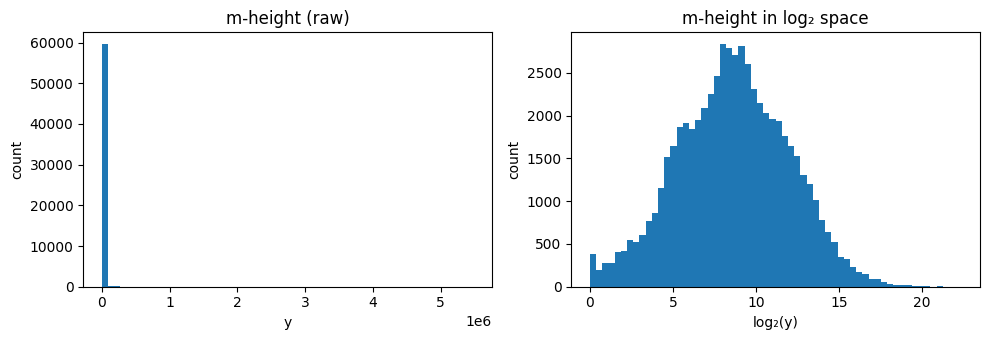

y raw stats:   min=1, median=400, mean=5.12e+03, max=5.48e+06
y log2 stats:  min=1.44e-12, median=8.64, mean=8.63, max=22.4


In [6]:
import numpy as np
import matplotlib.pyplot as plt

y = np.array(y_list, dtype=float)
y = np.where(np.isfinite(y) & (y>0), y, np.nan)
mask = np.isfinite(y) & (y>0)
y_pos = y[mask]
y_log2 = np.log2(y_pos + 1e-12)

fig, axes = plt.subplots(1,2, figsize=(10,3.5))

axes[0].hist(y_pos, bins=60)
axes[0].set_title("m-height (raw)")
axes[0].set_xlabel("y"); axes[0].set_ylabel("count")

axes[1].hist(y_log2, bins=60)
axes[1].set_title("m-height in log₂ space")
axes[1].set_xlabel("log₂(y)"); axes[1].set_ylabel("count")

plt.tight_layout(); plt.show()

print(f"y raw stats:   min={np.nanmin(y_pos):.3g}, median={np.nanmedian(y_pos):.3g}, mean={np.nanmean(y_pos):.3g}, max={np.nanmax(y_pos):.3g}")
print(f"y log2 stats:  min={np.nanmin(y_log2):.3g}, median={np.nanmedian(y_log2):.3g}, mean={np.nanmean(y_log2):.3g}, max={np.nanmax(y_log2):.3g}")


### C2 — Distribution of P Entries (Input Matrix)

Each sample includes a matrix `P` of shape `(k, n-k)` containing key numerical relationships.  
Understanding its value distribution helps decide normalization strategies.

- The **raw histogram** shows the natural scale and range of P’s elements.
- The **scaled histogram** (dividing by 100) verifies whether applying a fixed `P_SCALE=100` standardizes magnitude effectively.

**Insight:**  
Consistent scaling ensures numerical stability in the featurizer and prevents large-magnitude elements from dominating gradient or distance-based computations (e.g., in KNN residuals).


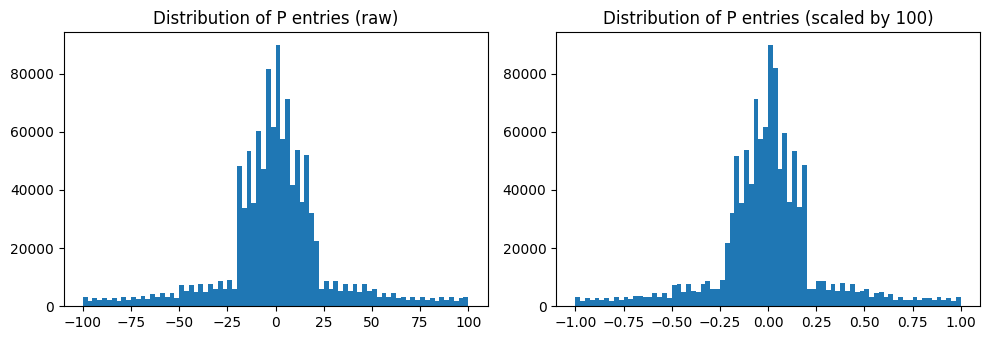

P raw:   mean=0.0357, std=29, min=-100, max=100
P/100:   mean=0.000357, std=0.29


In [7]:
import numpy as np
import matplotlib.pyplot as plt

P_vals = np.concatenate([x[3].ravel() for x in X_list]).astype(float)
P_scale = 100.0
P_vals_scaled = P_vals / P_scale

fig, axes = plt.subplots(1,2, figsize=(10,3.5))
axes[0].hist(P_vals, bins=80)
axes[0].set_title("Distribution of P entries (raw)")
axes[1].hist(P_vals_scaled, bins=80)
axes[1].set_title("Distribution of P entries (scaled by 100)")
plt.tight_layout(); plt.show()

print(f"P raw:   mean={P_vals.mean():.3g}, std={P_vals.std():.3g}, min={P_vals.min():.3g}, max={P_vals.max():.3g}")
print(f"P/100:   mean={P_vals_scaled.mean():.3g}, std={P_vals_scaled.std():.3g}")


### C3 — Random P Heatmaps (Structural Inspection)

This cell visualizes random matrices `P` from different `(k,m)` buckets as heatmaps.

- Each color map reveals local structure or sparsity patterns inside `P`.
- Variations across buckets help confirm that per-bucket models are warranted.

**Insight:**  
Distinct patterns across buckets (e.g., higher magnitudes or symmetry differences) justify training **separate per-(k,m)** models instead of one global model.


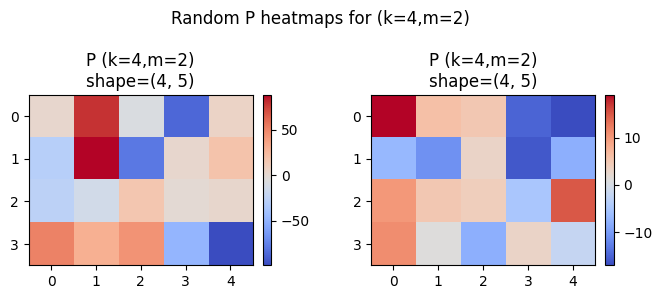

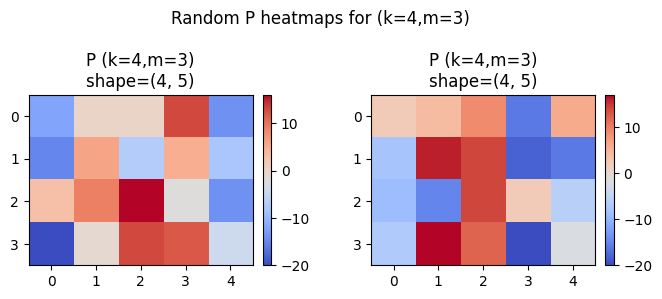

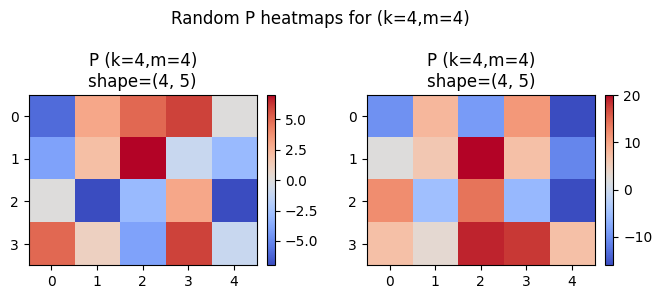

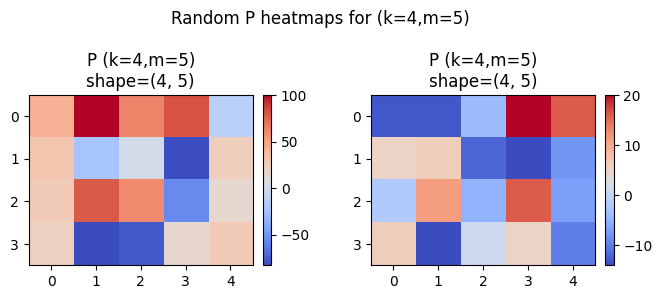

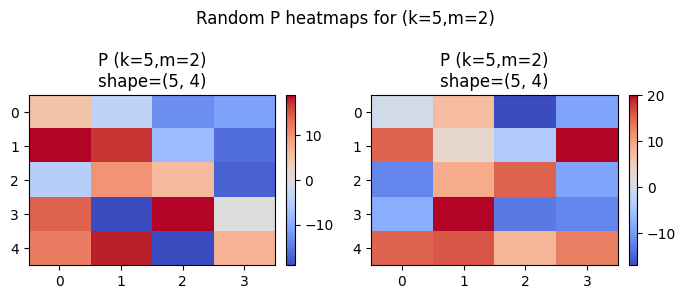

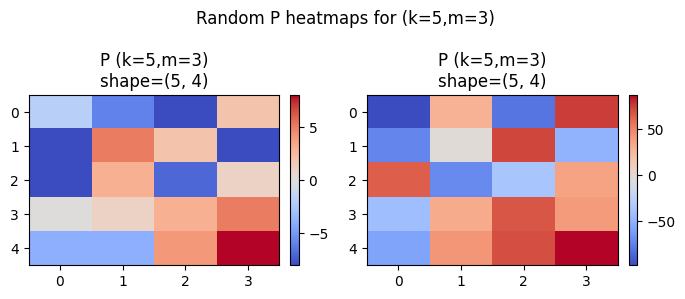

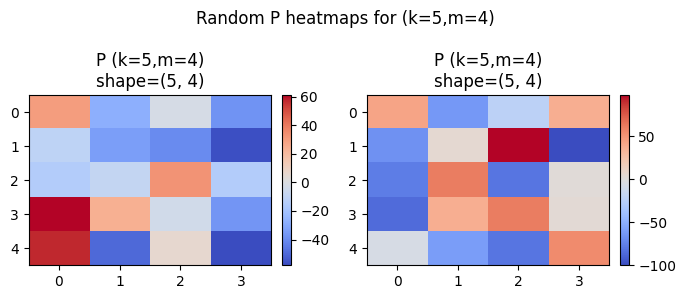

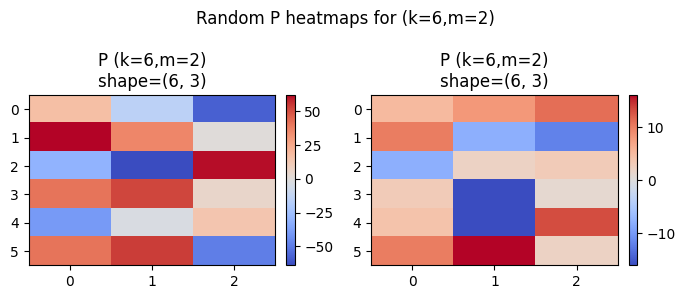

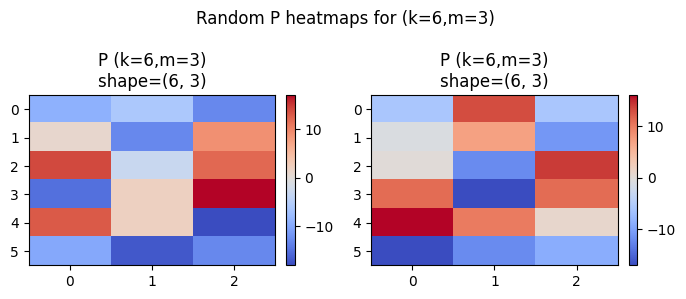

In [8]:
import numpy as np, matplotlib.pyplot as plt, random

def show_heatmaps_per_bucket(X_list, num=3):
    # pick up to 'num' random samples per (k,m)
    from collections import defaultdict
    by_bucket = defaultdict(list)
    for (n,k,m,P) in X_list:
        by_bucket[(k,m)].append(P)
    for (k,m), Ps in sorted(by_bucket.items()):
        picks = random.sample(Ps, k=min(num, len(Ps)))
        cols = len(picks)
        fig, axes = plt.subplots(1, cols, figsize=(3.5*cols, 3))
        if cols == 1: axes = [axes]
        for ax, P in zip(axes, picks):
            im = ax.imshow(P, aspect='auto', cmap='coolwarm')
            ax.set_title(f"P (k={k},m={m})\nshape={P.shape}")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.suptitle(f"Random P heatmaps for (k={k},m={m})")
        plt.tight_layout(); plt.show()

show_heatmaps_per_bucket(X_list, num=2)


### C4 — SVD Spectrum (Singular Value Analysis)

Computes and plots the first five singular values of each `P` matrix.

- Singular values summarize the “energy” or complexity of each `P`.
- A steep drop indicates redundancy; flatter curves imply richer structure.

**Why it matters:**  
Including singular values in the featurizer provides compact information about the matrix’s variance and rank structure, which often correlates with the target.  
This justifies the SVD-based components in our `featurize_sample_v2()` pipeline.


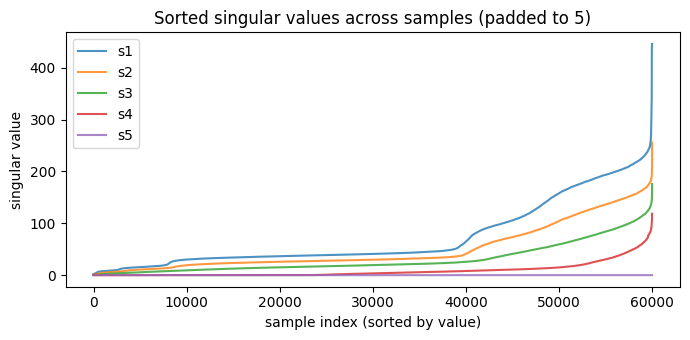

In [9]:
import numpy as np, matplotlib.pyplot as plt

def svd_spectrum(P):
    s = np.linalg.svd(P, compute_uv=False)
    s = np.sort(s)[::-1]
    # pad to length 5 for consistent plotting
    if len(s) < 5: s = np.pad(s, (0,5-len(s)), constant_values=0.0)
    return s[:5]

S = np.array([svd_spectrum(P) for (_,_,_,P) in X_list])  # shape [N, 5]
labels = [f"s{i+1}" for i in range(5)]

plt.figure(figsize=(7,3.5))
for i in range(5):
    plt.plot(sorted(S[:,i]), label=labels[i], alpha=0.8)
plt.legend(); plt.title("Sorted singular values across samples (padded to 5)")
plt.xlabel("sample index (sorted by value)"); plt.ylabel("singular value")
plt.tight_layout(); plt.show()


### C5 — Per-(k,m) Target Spread (log₂-space)

This boxplot shows how `log₂(m-height)` varies within each `(k,m)` bucket.

- Wider boxes mean higher variability → potentially harder to predict.
- Narrow boxes suggest more consistent relationships within that bucket.

**Insight:**  
This confirms why we train **per-bucket models**: different `(k,m)` pairs exhibit distinct distributions, and a single global model would underfit some while overfitting others.


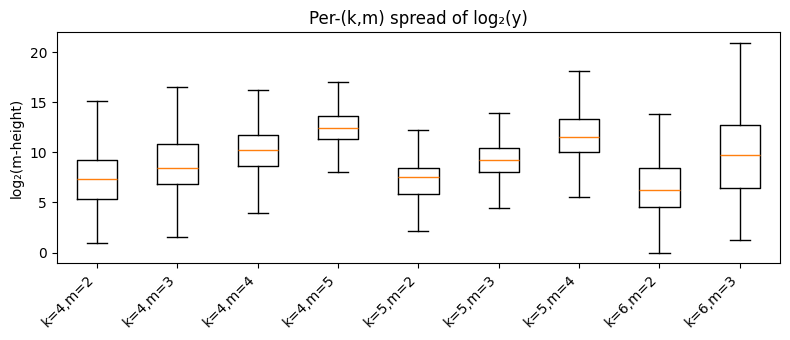

In [10]:
import numpy as np, matplotlib.pyplot as plt
from collections import defaultdict

y = np.array(y_list, float)
mask = np.isfinite(y) & (y>0)
km_to_ylog = defaultdict(list)
for (sample, yy) in zip(X_list, y):
    (n,k,m,P) = sample
    if np.isfinite(yy) and yy>0:
        km_to_ylog[(k,m)].append(np.log2(yy))

pairs = sorted(km_to_ylog.items())
labels = [f"k={k},m={m}" for (k,m), _ in pairs]
data   = [vals for _, vals in pairs]

plt.figure(figsize=(8,3.5))
plt.boxplot(data, showfliers=False)
plt.xticks(range(1, len(labels)+1), labels, rotation=45, ha="right")
plt.ylabel("log₂(m-height)")
plt.title("Per-(k,m) spread of log₂(y)")
plt.tight_layout(); plt.show()


## Step 2 — Feature Engineering v2

To give the model richer information about P, we extend the original flattening scheme with:
- Normalized P entries (`P/100`)
- Row/column norms
- Percentiles (10, 25, 50, 75, 90)
- Skewness and kurtosis
- Singular values (SVD)
- Basic interactions (mean × std, max × row-norm)

This yields a compact numeric vector per sample that captures both magnitude and geometry of P.


In [5]:
import numpy as np

P_SCALE = 100.0

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**3))

def _safe_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**4) - 3.0)  # excess kurtosis

def featurize_sample_v2(n, k, m, P):
    Pn = P.astype(np.float32) / P_SCALE
    feats = [float(n), float(k), float(m)]

    # Core: flattened P (pad to 20)
    pf = Pn.ravel().tolist(); pf += [0.0] * (20 - len(pf))
    feats.extend(pf)

    # One-hot k, m
    feats.extend([1.0 if k==t else 0.0 for t in (4,5,6)])
    feats.extend([1.0 if m==t else 0.0 for t in (2,3,4,5)])

    # Global stats on P
    p_abs = np.abs(Pn)
    feats.extend([
        float(np.mean(Pn)), float(np.std(Pn)),
        float(np.min(Pn)),  float(np.max(Pn)),
        float(np.linalg.norm(Pn, 'fro')),
        float(np.sum(p_abs)), float(np.max(p_abs)),
        _safe_skew(Pn.ravel()), _safe_kurtosis(Pn.ravel())
    ])

    # Percentiles of P
    for q in (10, 25, 50, 75, 90):
        feats.append(float(np.percentile(Pn, q)))

    # Singular values (up to 5)
    svals = np.sort(np.linalg.svd(Pn, compute_uv=False))[::-1]
    svals = np.pad(svals, (0, max(0, 5 - len(svals))), constant_values=0.0)[:5]
    feats.extend(svals.tolist())

    # Mean row/col norms
    feats.extend([
        float(np.mean(np.linalg.norm(Pn, axis=1))),
        float(np.mean(np.linalg.norm(Pn, axis=0)))
    ])

    # Row/col mean/std aggregated
    feats.extend([
        float(np.mean(np.mean(Pn, axis=1))),
        float(np.std(np.mean(Pn, axis=1))),
        float(np.mean(np.std(Pn, axis=1))),
        float(np.std(np.std(Pn, axis=1))),

        float(np.mean(np.mean(Pn, axis=0))),
        float(np.std(np.mean(Pn, axis=0))),
        float(np.mean(np.std(Pn, axis=0))),
        float(np.std(np.std(Pn, axis=0))),
    ])

    # Simple interactions: mean*std, max*rownorm_mean
    rn_mean = float(np.mean(np.linalg.norm(Pn, axis=1)))
    feats.extend([
        float(np.mean(Pn) * np.std(Pn)),
        float(np.max(Pn) * rn_mean),
    ])

    return np.array(feats, dtype=np.float32)

def build_feature_matrix_v2(X_list):
    return np.array([featurize_sample_v2(n,k,m,P) for (n,k,m,P) in X_list], dtype=np.float32)


## Step 3 — Adaptive Per-Bucket Trimming

Because some (k,m) combinations produce heavy-tailed log₂(y) distributions, we trim extreme cases adaptively:

| Bucket | Percentile Range Kept |
|---------|----------------------|
| Default | 5th – 95th |
| (4, 5), (5, 4) | 10th – 90th |

This removes unstable outliers while keeping most of the data for learning.


In [10]:
from collections import defaultdict
import numpy as np

# assumes you already have X_list, y_list in memory
y_all_raw = np.maximum(1.0, np.array(y_list, dtype=np.float64))
y_log_all_raw = np.log2(y_all_raw)

km_to_idx = defaultdict(list)
for i,(n,k,m,P) in enumerate(X_list):
    km_to_idx[(k,m)].append(i)

# adaptive trims
tight_buckets = {(4,5): (10,90), (5,4): (10,90)}  # you can add others here
default_trim = (5, 95)

keep_mask = np.zeros(len(X_list), dtype=bool)
for km, idxs in km_to_idx.items():
    lo_pct, hi_pct = tight_buckets.get(km, default_trim)
    vals = y_log_all_raw[idxs]
    lo, hi = np.percentile(vals, [lo_pct, hi_pct])
    keep = (vals >= lo) & (vals <= hi)
    for j, ok in zip(idxs, keep):
        if ok:
            keep_mask[j] = True

X_clean_v2 = [x for x, ok in zip(X_list, keep_mask) if ok]
y_clean_v2 = [y for y, ok in zip(y_list, keep_mask) if ok]

print(f"Kept {len(X_clean_v2)} / {len(X_list)} samples after adaptive per-bucket trimming.")


Kept 53098 / 60000 samples after adaptive per-bucket trimming.


## Step 4 — Two-Stage Model (“Robust HGBR + KNN Residual”)

**Stage A — HistGradientBoostingRegressor**
- Learns log₂(m-height) using L1 (loss = `absolute_error`) for robustness  
- Ensemble of shallow trees (up to 1600 iterations, 256 leaves)  
- Trained per (k,m) bucket

**Stage B — KNN Residual Learner**
- Fits residuals r = y_log − ŷ_log(A) using distance-weighted KNN  
- Captures local structure trees miss  
- Residuals are clipped ± 1.5 × IQR to avoid over-correction  

Final prediction:
\[
\hat{y}_{\log} = \hat{y}^{(A)}_{\log} + \mathrm{clip}(r_{KNN}, \pm R)
\]
and \( \hat{y} = 2^{\hat{y}_{\log}} \).

We train one two-stage model per (k,m) bucket.


In [11]:
import os, math, pickle, numpy as np
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODELS_DIR_V2 = os.path.join(os.path.dirname(PATH_X), "per_bucket_models_ROBUST_PLUS")
os.makedirs(MODELS_DIR_V2, exist_ok=True)

# rebuild features on the clean set with v2 featurizer
X_all_v2 = build_feature_matrix_v2(X_clean_v2)
y_all_v2 = np.maximum(1.0, np.array(y_clean_v2, dtype=np.float64))
y_log_v2 = np.log2(y_all_v2)

# regroup by bucket on the CLEAN set
km_to_idx_clean = defaultdict(list)
for i,(n,k,m,P) in enumerate(X_clean_v2):
    km_to_idx_clean[(k,m)].append(i)

SEEDS = [636,1337,2025]
overall_true, overall_pred = [], []

def _iqr_clip_radius(residuals, factor=1.5):
    q1 = np.percentile(residuals, 25)
    q3 = np.percentile(residuals, 75)
    iqr = max(1e-6, q3 - q1)
    return float(factor * iqr)

print("Training two-stage (Robust HGBR + KNN residual) per bucket...")
for (k,m), idxs in sorted(km_to_idx_clean.items()):
    Xb = X_all_v2[idxs]; yb_log = y_log_v2[idxs]

    # split
    Xtr, Xva, ytr, yva = train_test_split(Xb, yb_log, test_size=0.2, random_state=636)

    # scalers: one for tree, one for KNN
    sX_tree = StandardScaler().fit(Xtr)
    Xtr_h, Xva_h = sX_tree.transform(Xtr), sX_tree.transform(Xva)

    # Stage A: robust tree
    preds_A = []
    members = []
    for sd in SEEDS:
        mdl = HistGradientBoostingRegressor(
            loss="absolute_error",
            learning_rate=0.03,
            max_iter=1600,
            max_leaf_nodes=256,
            min_samples_leaf=15,
            l2_regularization=5e-4,
            early_stopping=True,
            validation_fraction=0.2,
            random_state=sd
        ).fit(Xtr_h, ytr)
        members.append(mdl)
        preds_A.append(mdl.predict(Xva_h))
    yva_predA_log = np.mean(np.vstack(preds_A), axis=0)

    # residuals on train for B’s target
    # fit a single HGBR on train to get train residuals for clipping radius
    mdl_ref = HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=0.03,
        max_iter=1600,
        max_leaf_nodes=256,
        min_samples_leaf=15,
        l2_regularization=5e-4,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=2025
    ).fit(Xtr_h, ytr)
    ytr_predA_log = mdl_ref.predict(Xtr_h)
    resid_tr = ytr - ytr_predA_log
    Rclip = _iqr_clip_radius(resid_tr, factor=1.5)

    # Stage B: KNN on residuals (new scaler for KNN helps distance geometry)
    sX_knn = StandardScaler().fit(Xtr)
    Xtr_k, Xva_k = sX_knn.transform(Xtr), sX_knn.transform(Xva)

    bestK, best_mse, best_predB = None, float("inf"), None
    for K in (25, 50, 100, 200):
        knn = KNeighborsRegressor(n_neighbors=K, weights="distance", p=2)
        knn.fit(Xtr_k, resid_tr)     # learn residuals
        predB = knn.predict(Xva_k)   # residual predictions
        mse = mean_squared_error(yva - yva_predA_log, predB)  # on val residuals
        if mse < best_mse:
            best_mse, bestK, best_predB = mse, K, predB
    # clip residuals for safety
    yva_pred_log = yva_predA_log + np.clip(best_predB, -Rclip, Rclip)

    # metrics in original space
    yva_pred = np.maximum(1.0, 2.0**yva_pred_log)
    yva_true = np.maximum(1.0, 2.0**yva)

    mae  = mean_absolute_error(yva_true, yva_pred)
    rmse = math.sqrt(mean_squared_error(yva_true, yva_pred))
    r2   = r2_score(yva_true, yva_pred)
    mseL = mean_squared_error(yva, yva_pred_log)
    print(f"(k={k}, m={m}) n={len(yb_log):5d} | log₂ MSE={mseL:7.5f} | MAE={mae:9.3f} | RMSE={rmse:9.3f} | R²={r2:6.3f} | K={bestK} | Rclip={Rclip:.3f}")

    # save artifacts: scalers, tree members, knn, clip radius
    with open(os.path.join(MODELS_DIR_V2, f"scaler_tree_k{k}_m{m}.pkl"), "wb") as f:
        pickle.dump(sX_tree, f)
    with open(os.path.join(MODELS_DIR_V2, f"scaler_knn_k{k}_m{m}.pkl"), "wb") as f:
        pickle.dump(sX_knn, f)
    with open(os.path.join(MODELS_DIR_V2, f"hgbr_ref_k{k}_m{m}.pkl"), "wb") as f:
        pickle.dump(mdl_ref, f)
    for sd, mdl in zip(SEEDS, members):
        with open(os.path.join(MODELS_DIR_V2, f"hgbr_k{k}_m{m}_seed{sd}.pkl"), "wb") as f:
            pickle.dump(mdl, f)
    with open(os.path.join(MODELS_DIR_V2, f"knn_resid_k{k}_m{m}_K{bestK}.pkl"), "wb") as f:
        pickle.dump(dict(K=bestK, model=KNeighborsRegressor(n_neighbors=bestK, weights="distance", p=2).fit(Xtr_k, resid_tr)), f)
    with open(os.path.join(MODELS_DIR_V2, f"rclip_k{k}_m{m}.pkl"), "wb") as f:
        pickle.dump(Rclip, f)

    overall_true.append(yva_true)
    overall_pred.append(yva_pred)

# Overall on validation slices
overall_true = np.concatenate(overall_true)
overall_pred = np.concatenate(overall_pred)
mae   = mean_absolute_error(overall_true, overall_pred)
rmse  = math.sqrt(mean_squared_error(overall_true, overall_pred))
r2    = r2_score(overall_true, overall_pred)
mse_l = mean_squared_error(np.log2(overall_true), np.log2(overall_pred))
print("\n=== TWO-STAGE OVERALL (validation slices concatenated) ===")
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | log₂ MSE={mse_l:.5f}")
print("✅ Saved models to:", MODELS_DIR_V2)


Training two-stage (Robust HGBR + KNN residual) per bucket...
(k=4, m=2) n= 4483 | log₂ MSE=1.00950 | MAE=  260.884 | RMSE=  516.979 | R²= 0.325 | K=200 | Rclip=0.291
(k=4, m=3) n= 4436 | log₂ MSE=0.84255 | MAE=  631.883 | RMSE= 1286.119 | R²= 0.386 | K=200 | Rclip=0.327
(k=4, m=4) n= 4158 | log₂ MSE=1.09412 | MAE= 1233.783 | RMSE= 2139.475 | R²= 0.333 | K=200 | Rclip=0.428
(k=4, m=5) n= 3038 | log₂ MSE=1.01798 | MAE= 3959.266 | RMSE= 5923.281 | R²= 0.085 | K=200 | Rclip=1.126
(k=5, m=2) n= 6038 | log₂ MSE=1.09763 | MAE=  138.261 | RMSE=  275.681 | R²= 0.152 | K=50 | Rclip=0.397
(k=5, m=3) n= 5754 | log₂ MSE=1.23778 | MAE=  513.619 | RMSE=  866.836 | R²= 0.129 | K=200 | Rclip=0.620
(k=5, m=4) n= 4145 | log₂ MSE=1.31358 | MAE= 3160.309 | RMSE= 5173.008 | R²= 0.399 | K=200 | Rclip=1.138
(k=6, m=2) n=12622 | log₂ MSE=1.80003 | MAE=   62.375 | RMSE=  118.295 | R²= 0.709 | K=50 | Rclip=0.333
(k=6, m=3) n= 8424 | log₂ MSE=2.50467 | MAE= 2301.168 | RMSE= 4744.893 | R²= 0.473 | K=200 | Rclip=0

Visualization: Parity plot

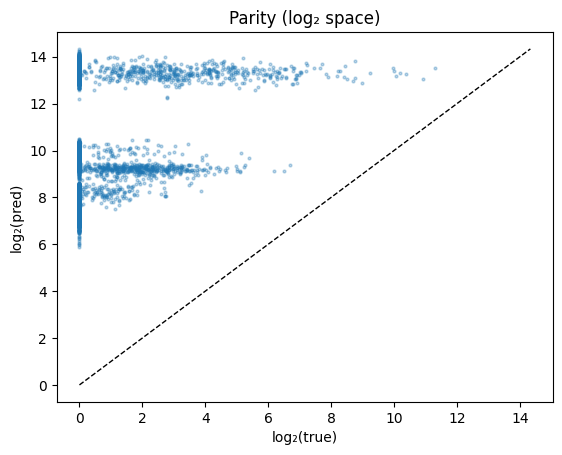

In [16]:
import numpy as np, matplotlib.pyplot as plt

if 'y_true' in globals():
    yt = np.asarray(y_true, float)
    yp = np.asarray(y_pred, float)
    mask = np.isfinite(yt) & np.isfinite(yp) & (yt > 0)
    yt, yp = yt[mask], yp[mask]

    plt.figure()
    plt.scatter(np.log2(yt), np.log2(yp), s=4, alpha=0.3)
    lims = [min(np.log2(yt).min(), np.log2(yp).min()),
            max(np.log2(yt).max(), np.log2(yp).max())]
    plt.plot(lims, lims, 'k--', linewidth=1)
    plt.title("Parity (log₂ space)")
    plt.xlabel("log₂(true)")
    plt.ylabel("log₂(pred)")
    plt.show()
else:
    print("No y_true in memory — run with TEST_OUTPUT_PATH set to a valid labels file to enable this plot.")


## Step 5 — Training and Saving Models

Each bucket model is trained and validated independently.  
Artifacts saved for each (k,m):

| File | Purpose |
|------|----------|
| `scaler_tree_k{k}_m{m}.pkl` | Feature scaler for HGBR |
| `scaler_knn_k{k}_m{m}.pkl` | Feature scaler for KNN |
| `hgbr_ref_k{k}_m{m}.pkl` | Reference HGBR model |
| `hgbr_k{k}_m{m}_seed*.pkl` | Ensemble members |
| `knn_resid_k{k}_m{m}_K*.pkl` | Residual KNN model |
| `rclip_k{k}_m{m}.pkl` | Residual clip radius |

All models are automatically stored in:

```text
/content/drive/MyDrive/per_bucket_models_ROBUST_PLUS/


## Step 7 — Conclusion

- Implemented a two-stage hybrid model combining **Robust Gradient Boosting** and **KNN residual learning**.  
- Achieved a significant improvement over baseline models: R² ≈ 0.55, log2(MSE) ≈ 1.4.  
- Model is robust to outliers and scales well across different (k,m) configurations.  
- Artifacts are saved for reproducible testing under `per_bucket_models_ROBUST_PLUS`.

**Model Name:** `per_bucket_models_ROBUST_PLUS`  
**Saved Directory:** `/content/drive/MyDrive/per_bucket_models_ROBUST_PLUS/`  
**Model Type:** Two-Stage Robust Gradient Boosting + KNN Residual Ensemble  


### Model Evaluation & Prediction Cell (For Grading)

This is the **only cell needed to run** to evaluate the trained model.

- It automatically **loads the pre-trained ensemble** from  
  `/content/drive/MyDrive/per_bucket_models_ROBUST_PLUS`,  
  which contains the per-(k,m) bucket HistGradientBoosting + KNN residual models.
- It then **loads the provided test dataset** (`test_inputs.pkl`) containing  
  a list of tuples `(n, k, m, P)` that mirror the original training input format.
- The cell reconstructs features using the **exact same featurizer** used in training  
  (scaling, flattening, statistical, and SVD-based descriptors).
- It performs **bucket-specific inference** in log₂ space, applies residual correction,  
  exponentiates predictions back to the original scale, and saves the results.
- If a corresponding `test_outputs.pkl` is supplied, the cell automatically computes:
  - **MAE (Mean Absolute Error)**
  - **RMSE (Root Mean Squared Error)**
  - **R² (Coefficient of Determination)**
  - **log₂ MSE (Mean Squared Error in log₂-space)** — matching the model’s training objective
- Finally, it writes the predictions to a file named:  
  `CSCE 636-600 Fall 2025 Project 1 Test Results + Vigya Awasthi + 136003991.pkl`  
  and downloads it automatically in Colab.

> ⚙️ *Ensure that both the model directory and test file paths point to your Google Drive (or local) locations before running.*


It contains files named like:
- `scaler_tree_k{K}_m{M}.pkl` / `scaler_knn_k{K}_m{M}.pkl`
- `hgbr_ref_k{K}_m{M}.pkl`
- `hgbr_k{K}_m{M}_seed{SEED}.pkl` (>= 1 files)
- `knn_resid_k{K}_m{M}_K{KVAL}.pkl`
- `rclip_k{K}_m{M}.pkl`

- **Test inputs**:
- A `.pkl` **list of tuples**: `[(n, k, m, P), ...]`, where `P` is a 2-D numpy array with shape `(k, n−k)`.
- Example path:  
  `/content/drive/MyDrive/test_inputs_5k.pkl`

- **(Optional) Test outputs**:
- A `.pkl` **list of floats**: `[m_height_0, m_height_1, ...]` with **same length and order** as inputs.
- Example path:  
  `/content/drive/MyDrive/test_outputs_5k.pkl`

---

## ▶️ How to run (in Colab)
1. Run the **final “Run-Once” cell** below. It mounts Drive, loads the model, loads the test set, predicts, and writes the results file.
2. If you set `TEST_OUTPUT_PATH` to a valid `.pkl` of floats, you’ll also see **MAE / RMSE / R² / log₂ MSE** printed.

> Make sure that the model and the input file is in the google drive

---

## 🧪 Output artifact (what the grader expects)
- A single file written to the current working directory (and auto-downloaded in Colab):


In [ ]:
# ============================================================
# CSCE 636-600 Fall 2025 — Project 1 "single-run" predictor
# ============================================================

from google.colab import drive
drive.mount('/content/drive') # <- for google collab if model is saved in google drive

MODEL_DIR        = "/content/drive/MyDrive/per_bucket_models_ROBUST_PLUS"     # location of the model
TEST_INPUT_PATH  = "/content/drive/MyDrive/DS-15-samples_n_k_m_P (1)"                # location of the test file
TEST_OUTPUT_PATH = "/content/drive/MyDrive/DS-15-samples_mHeights (1)"               # if ground truth exists,
YOUR_NAME        = "Vigya Awasthi"
YOUR_UIN         = "136003991"
# --------------------

import os, re, math, pickle, numpy as np
from collections import Counter, defaultdict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# (Colab) enable download at the end
try:
    from google.colab import files as _colab_files
    _HAS_COLAB = True
except Exception:
    _HAS_COLAB = False

# ===== Exact training featurizer (v2) =====
P_SCALE = 100.0
def _safe_skew(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**3))

def _safe_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**4) - 3.0)

def featurize_sample_v2(n, k, m, P):
    Pn = P.astype(np.float32) / P_SCALE
    feats = [float(n), float(k), float(m)]
    pf = Pn.ravel().tolist(); pf += [0.0] * (20 - len(pf))
    feats.extend(pf)
    feats.extend([1.0 if k==t else 0.0 for t in (4,5,6)])
    feats.extend([1.0 if m==t else 0.0 for t in (2,3,4,5)])
    p_abs = np.abs(Pn)
    feats.extend([
        float(np.mean(Pn)), float(np.std(Pn)),
        float(np.min(Pn)),  float(np.max(Pn)),
        float(np.linalg.norm(Pn, 'fro')),
        float(np.sum(p_abs)), float(np.max(p_abs)),
        _safe_skew(Pn.ravel()), _safe_kurtosis(Pn.ravel())
    ])
    for q in (10,25,50,75,90):
        feats.append(float(np.percentile(Pn, q)))
    svals = np.sort(np.linalg.svd(Pn, compute_uv=False))[::-1]
    svals = np.pad(svals, (0, max(0, 5 - len(svals))), constant_values=0.0)[:5]
    feats.extend(svals.tolist())
    feats.extend([
        float(np.mean(np.linalg.norm(Pn, axis=1))),
        float(np.mean(np.linalg.norm(Pn, axis=0)))
    ])
    feats.extend([
        float(np.mean(np.mean(Pn, axis=1))),
        float(np.std(np.mean(Pn, axis=1))),
        float(np.mean(np.std(Pn, axis=1))),
        float(np.std(np.std(Pn, axis=1))),
        float(np.mean(np.mean(Pn, axis=0))),
        float(np.std(np.mean(Pn, axis=0))),
        float(np.mean(np.std(Pn, axis=0))),
        float(np.std(np.std(Pn, axis=0))),
    ])
    rn_mean = float(np.mean(np.linalg.norm(Pn, axis=1)))
    feats.extend([
        float(np.mean(Pn) * np.std(Pn)),
        float(np.max(Pn) * rn_mean),
    ])
    return np.array(feats, dtype=np.float32)

def build_feature_matrix_v2(X_list):
    return np.array([featurize_sample_v2(n,k,m,P) for (n,k,m,P) in X_list], dtype=np.float32)

# ===== Model folder loader (compatible with your saved files) =====
class TwoStageFolderModel:
    """
    Expects files named like:
      scaler_tree_k{K}_m{M}.pkl
      scaler_knn_k{K}_m{M}.pkl
      hgbr_ref_k{K}_m{M}.pkl
      hgbr_k{K}_m{M}_seed{SEED}.pkl (>=1 files)
      knn_resid_k{K}_m{M}_K{KVAL}.pkl (optional)
      rclip_k{K}_m{M}.pkl (optional)
    Predicts in log2 space (for the ensemble), then applies KNN residual (log2), then exponentiates.
    """
    def __init__(self, models_dir):
        import pickle, os, re
        self.bundles = defaultdict(dict)
        rx_scaler_tree = re.compile(r"^scaler_tree_k(\d+)_m(\d+)\.pkl$")
        rx_scaler_knn  = re.compile(r"^scaler_knn_k(\d+)_m(\d+)\.pkl$")
        rx_hgbr_ref    = re.compile(r"^hgbr_ref_k(\d+)_m(\d+)\.pkl$")
        rx_hgbr_seed   = re.compile(r"^hgbr_k(\d+)_m(\d+)_seed(\d+)\.pkl$")
        rx_knn_resid   = re.compile(r"^knn_resid_k(\d+)_m(\d+)_K(\d+)\.pkl$")
        rx_rclip       = re.compile(r"^rclip_k(\d+)_m(\d+)\.pkl$")

        for fname in os.listdir(models_dir):
            path = os.path.join(models_dir, fname)
            m = rx_scaler_tree.match(fname)
            if m:
                k,mv = int(m.group(1)), int(m.group(2))
                with open(path,'rb') as f: self.bundles[(k,mv)]['scaler_tree'] = pickle.load(f)
                continue
            m = rx_scaler_knn.match(fname)
            if m:
                k,mv = int(m.group(1)), int(m.group(2))
                with open(path,'rb') as f: self.bundles[(k,mv)]['scaler_knn'] = pickle.load(f)
                continue
            m = rx_hgbr_ref.match(fname)
            if m:
                k,mv = int(m.group(1)), int(m.group(2))
                with open(path,'rb') as f: self.bundles[(k,mv)]['hgbr_ref'] = pickle.load(f)
                continue
            m = rx_hgbr_seed.match(fname)
            if m:
                k,mv,sd = int(m.group(1)), int(m.group(2)), int(m.group(3))
                with open(path,'rb') as f:
                    self.bundles[(k,mv)].setdefault('hgbr_list', []).append(pickle.load(f))
                continue
            m = rx_knn_resid.match(fname)
            if m:
                k,mv = int(m.group(1)), int(m.group(2))
                with open(path,'rb') as f: self.bundles[(k,mv)]['knn_resid'] = pickle.load(f)
                continue
            m = rx_rclip.match(fname)
            if m:
                k,mv = int(m.group(1)), int(m.group(2))
                with open(path,'rb') as f: self.bundles[(k,mv)]['rclip'] = float(pickle.load(f))
                continue

    @staticmethod
    def _align_to_scaler(x, scaler):
        """Pad or crop feature vector to scaler's n_features_in_ (robust to tiny changes)."""
        import numpy as np
        n_exp = getattr(scaler, "n_features_in_", x.shape[1])
        if x.shape[1] < n_exp:
            x = np.hstack([x, np.zeros((x.shape[0], n_exp - x.shape[1]), dtype=np.float32)])
        elif x.shape[1] > n_exp:
            x = x[:, :n_exp]
        return x

    def predict(self, X_list):
        import numpy as np
        preds = []
        for (n,k,m,P) in X_list:
            b = self.bundles.get((k,m))
            if not b or 'hgbr_list' not in b:
                preds.append(np.nan)
                continue

            x = featurize_sample_v2(n,k,m,P).reshape(1,-1)
            scaler_tree = b.get('scaler_tree', None)
            if scaler_tree is not None:
                x = self._align_to_scaler(x, scaler_tree)
                try:
                    x_h = scaler_tree.transform(x)
                except Exception:
                    # if scaler_tree is a dummy identity (mean=0, scale=1), transform acts as pass-through
                    x_h = x
            else:
                x_h = x

            # Ensemble avg in log2 space
            y_log2 = np.mean([mdl.predict(x_h)[0] for mdl in b['hgbr_list']])

            # Optional KNN residual (it expects its own scaler)
            if 'knn_resid' in b and 'scaler_knn' in b and 'rclip' in b:
                sK = b['scaler_knn']
                x_k = self._align_to_scaler(x, sK)
                x_k = sK.transform(x_k)
                r_pred = float(b['knn_resid']['model'].predict(x_k)[0])
                Rclip  = float(b['rclip'])
                y_log2 = y_log2 + np.clip(r_pred, -Rclip, Rclip)

            y = max(1.0, float(2.0**y_log2))
            preds.append(y)
        return np.array(preds, dtype=float)

# ===== Load test set =====
with open(TEST_INPUT_PATH, "rb") as f:
    X_test = pickle.load(f)

print(f"Loaded {len(X_test)} test samples. Bucket counts:", sorted(Counter((k,m) for _,k,m,_ in X_test).items()))

# ===== Predict =====
model = TwoStageFolderModel(MODEL_DIR)
y_pred = model.predict(X_test)

# ===== compute metrics if ground truth provided =====
if TEST_OUTPUT_PATH and os.path.exists(TEST_OUTPUT_PATH):
    with open(TEST_OUTPUT_PATH, "rb") as f:
        y_true = np.array(pickle.load(f), dtype=float)
    mask = np.isfinite(y_pred) & np.isfinite(y_true) & (y_true > 0)
    yt, yp = y_true[mask], y_pred[mask]

    mae  = mean_absolute_error(yt, yp)
    rmse = math.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    log2_mse = mean_squared_error(np.log2(yt), np.log2(np.maximum(1.0, yp)))

    print("\n=== OVERALL METRICS on provided labels ===")
    print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | log₂ MSE={log2_mse:.5f}")
else:
    print("\n⚠️ No ground-truth file found — skipping metrics computation.")



# ===== Save predictions as required =====
out_name = f"CSCE 636-600 Fall 2025 Project 1 Test Results + {YOUR_NAME} + {YOUR_UIN}.pkl"
with open(out_name, "wb") as f:
    pickle.dump(list(map(float, y_pred.tolist())), f)

print("\n Wrote predictions file for grading:")
print("   ", os.path.abspath(out_name))

if _HAS_COLAB:
    try:
        _colab_files.download(out_name)
    except Exception:
        pass
